In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud
from transformers import RobertaTokenizer, XLNetTokenizer
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

d:\SEMESTER 6 - Non Drive\Text Mining\AOL_TextMining_FakeNewsDetection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load test dataset
try:
    df_test = pd.read_csv('./data/test/test.csv')
except FileNotFoundError:
    print("Dataset not found at ./data/test/test.csv")
    
# Load train dataset for comparison
try:
    df_train = pd.read_csv('./data/train/train.csv')
except FileNotFoundError:
    print("Dataset not found at ./data/train/train.csv")

## Dataset Overview

In [3]:
print("Shape dataset:", df_test.shape)
print("Jumlah baris:", df_test.shape[0])
print("Jumlah kolom:", df_test.shape[1])
print("Nama kolom:", list(df_test.columns))
print("\nTipe data:\n", df_test.dtypes)

print("\nSample data:")
df_test.head()

Shape dataset: (25413, 3)
Jumlah baris: 25413
Jumlah kolom: 3
Nama kolom: ['Body ID', 'articleBody', 'Headline']

Tipe data:
 Body ID         int64
articleBody    object
Headline       object
dtype: object

Sample data:


,Body ID,articleBody,Headline
0,1,Al-Sisi has denied Israeli reports stating tha...,Apple installing safes in-store to protect gol...
1,1,Al-Sisi has denied Israeli reports stating tha...,El-Sisi denies claims he'll give Sinai land to...
2,1,Al-Sisi has denied Israeli reports stating tha...,Apple to keep gold Watch Editions in special i...
3,1,Al-Sisi has denied Israeli reports stating tha...,Apple Stores to Keep Gold “Edition” Apple Watc...
4,1,Al-Sisi has denied Israeli reports stating tha...,South Korean woman's hair 'eaten' by robot vac...


## Analisis Data Null

In [5]:
null_counts = df_test.isnull().sum()
null_percentages = (null_counts / len(df_test)) * 100
null_df = pd.DataFrame({'Missing Values': null_counts, 'Percentage (%)': null_percentages})
display(null_df)

,Missing Values,Percentage (%)
Body ID,0,0.0
articleBody,0,0.0
Headline,0,0.0


**Kesimpulan**: Tidak terdapat data Null pada data test.

## Analisis Data Duplikat

In [8]:
dup_row = df_test.duplicated().sum()

print("Data Duplikat: ", dup_row)

if dup_row > 0:
    print("Contoh Duplikat:")
    display(df_test[df_test.duplicated(keep=False)].sort_values('Headline').head())

Data Duplikat:  242
Contoh Duplikat:


,Body ID,articleBody,Headline
10728,1287,"Notorious murderer Charles Manson, 80, is prob...",Charles Manson’s fiancee allegedly wanted to m...
24664,2503,She apparently hoped tourist attraction would ...,Charles Manson’s fiancee allegedly wanted to m...
24659,2503,She apparently hoped tourist attraction would ...,Charles Manson’s fiancee allegedly wanted to m...
4048,491,Apple may boost the amount of internal RAM and...,Charles Manson’s fiancee allegedly wanted to m...
4052,491,Apple may boost the amount of internal RAM and...,Charles Manson’s fiancee allegedly wanted to m...


**Kesimpulan**: Terdapat 242 data baris yang duplikat.

## Analisis Headline

Statistik Deskriptif Karakter & Kata (Headline):


,headline_char_length,headline_word_count
count,25413.000000,25413.000000
mean,69.780231,11.149687
std,26.146399,4.210821
min,9.000000,1.000000
25%,54.000000,9.000000
50%,67.000000,11.000000
75%,80.000000,13.000000
max,245.000000,31.000000


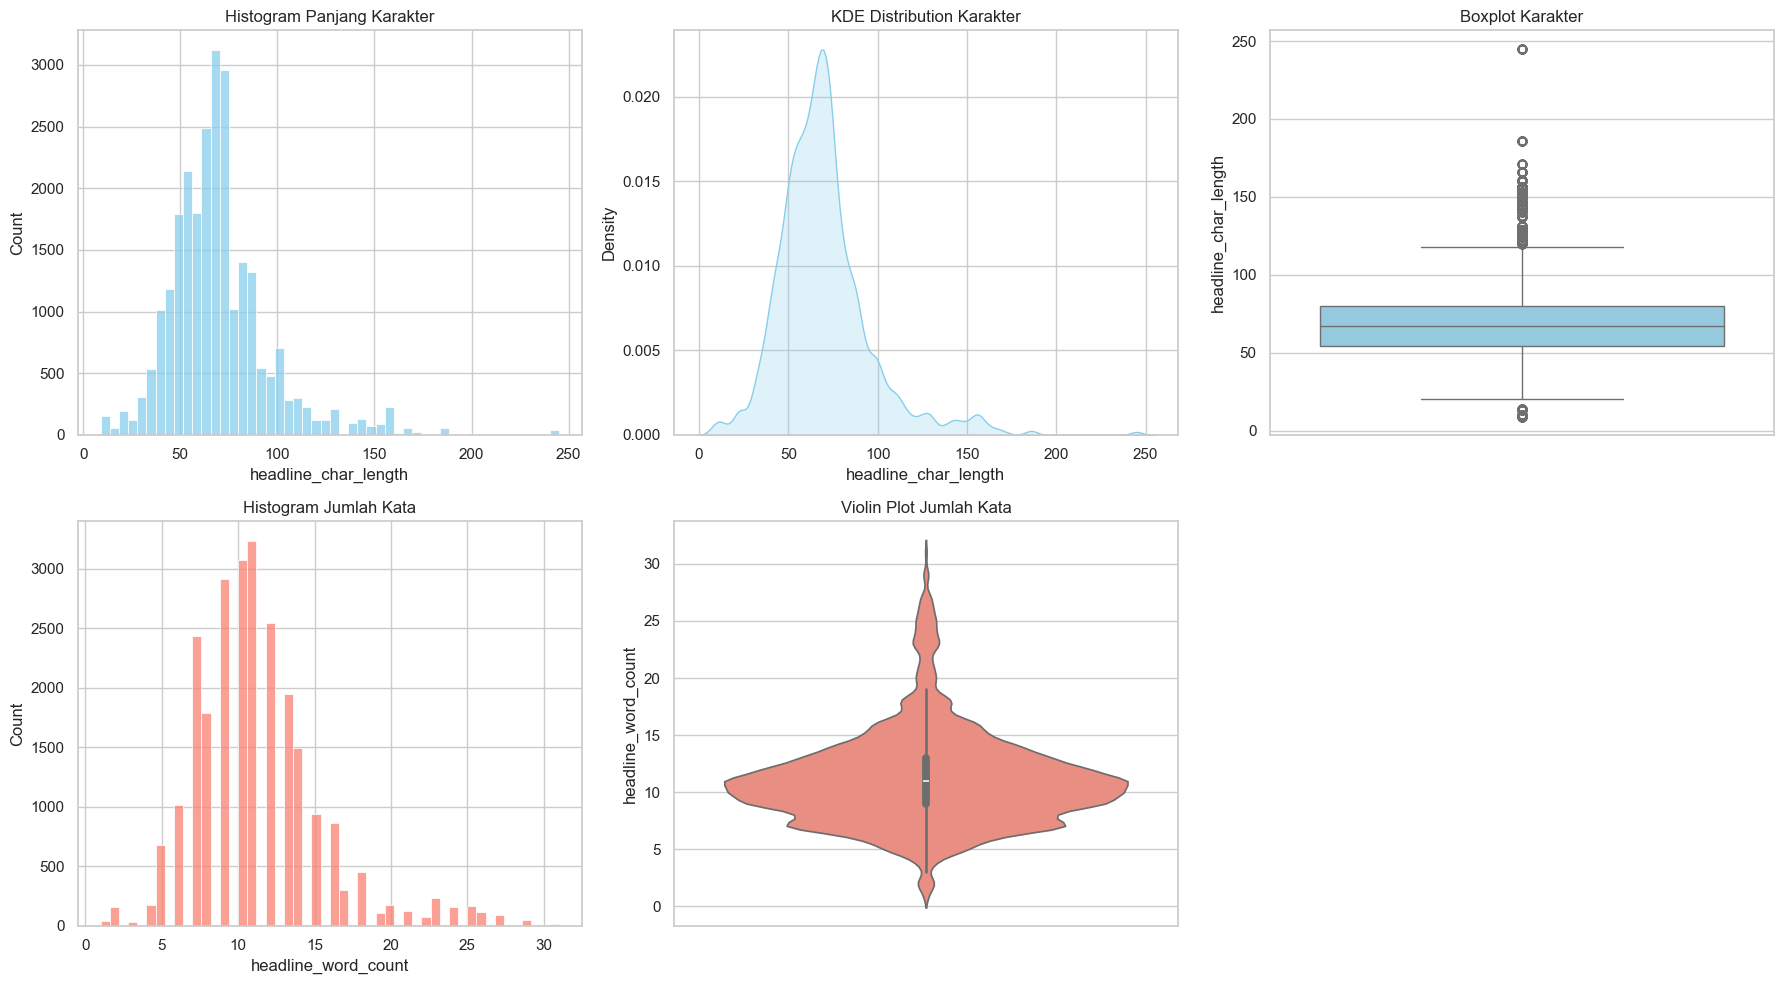

In [9]:
df_test['headline_char_length'] = df_test['Headline'].apply(lambda x: len(str(x)))
df_test['headline_word_count'] = df_test['Headline'].apply(lambda x: len(str(x).split()))

print("Statistik Deskriptif Karakter & Kata (Headline):")
display(df_test[['headline_char_length', 'headline_word_count']].describe())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Character Length
sns.histplot(df_test['headline_char_length'], bins=50, kde=False, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram Panjang Karakter')

sns.kdeplot(df_test['headline_char_length'], fill=True, ax=axes[1], color='skyblue')
axes[1].set_title('KDE Distribution Karakter')

sns.boxplot(y=df_test['headline_char_length'], ax=axes[2], color='skyblue')
axes[2].set_title('Boxplot Karakter')

# Word Count
sns.histplot(df_test['headline_word_count'], bins=50, kde=False, ax=axes[3], color='salmon')
axes[3].set_title('Histogram Jumlah Kata')

sns.violinplot(y=df_test['headline_word_count'], ax=axes[4], color='salmon')
axes[4].set_title('Violin Plot Jumlah Kata')

axes[5].axis('off')

plt.tight_layout()
plt.show()

**Kesimpulan**: Teks headline pada data test ini sangat ringkas dan konsisten. Rata-rata headline hanya terdiri dari 11 kata (sekitar 70 karakter), dengan panjang maksimal yang hanya mencapai 31 kata. Ukuran yang sangat pendek ini sangat ideal karena tidak akan memakan banyak porsi kuota token saat nantinya digabungkan dengan article body untuk diproses oleh model.

## Analisis Article Body

Statistik Deskriptif Karakter & Kata (Article Body):


,body_char_length,body_word_count
count,25413.000000,25413.000000
mean,2075.491677,347.468736
std,1836.193163,303.882611
min,29.000000,5.000000
25%,1086.000000,181.000000
50%,1673.000000,282.000000
75%,2535.000000,428.000000
max,19815.000000,3257.000000


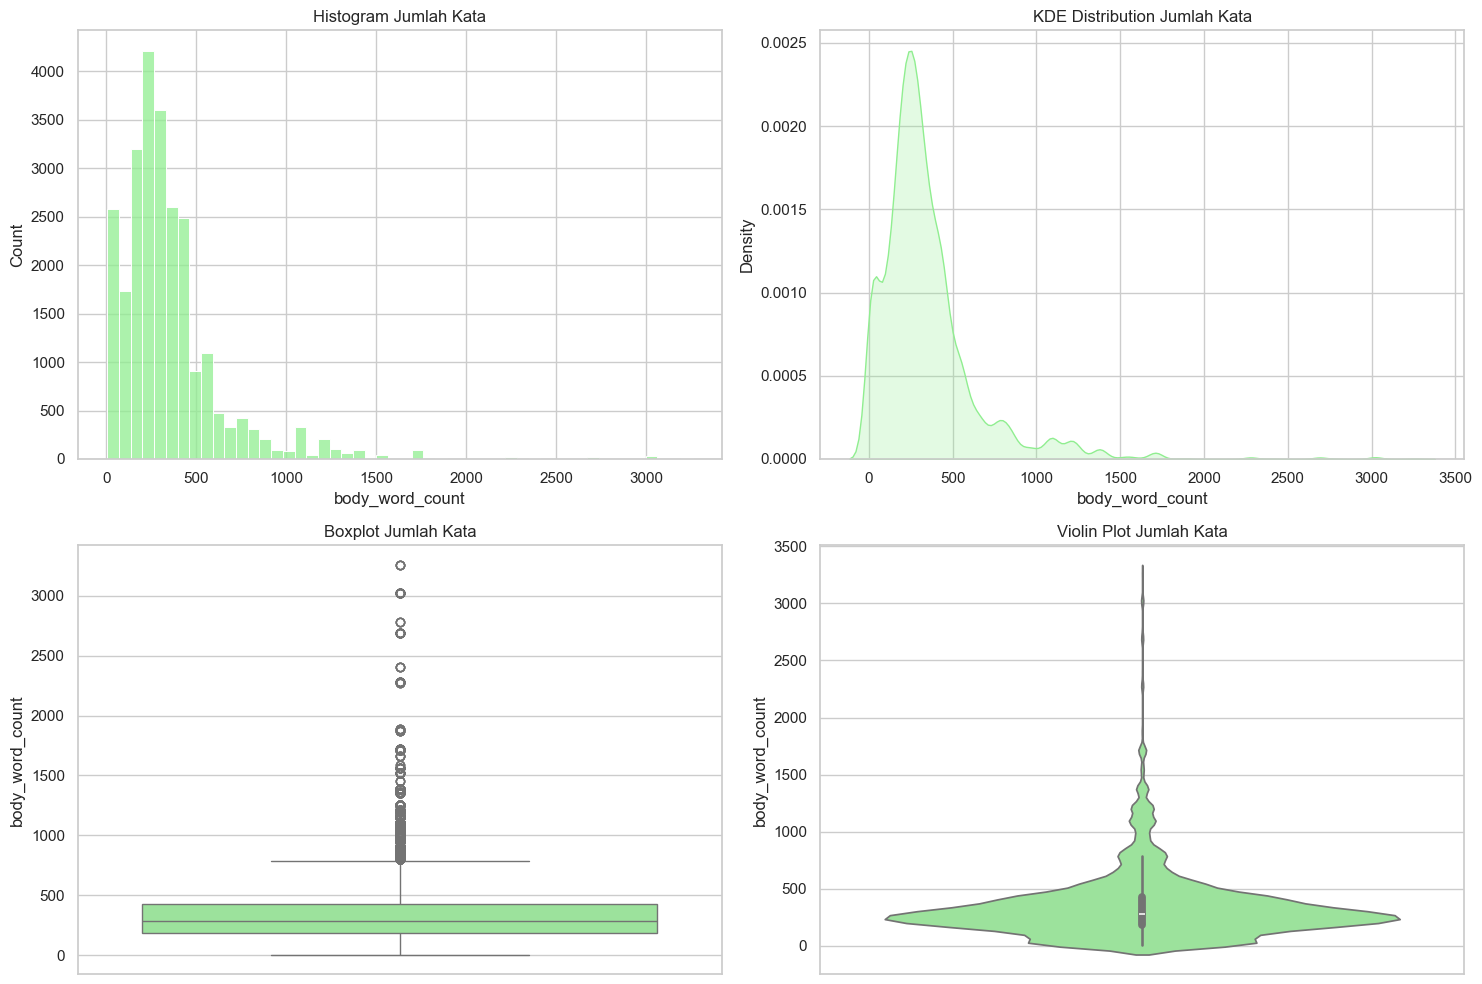

Artikel dengan Panjang Ekstrem (Top 5 Terpanjang):


,Headline,body_word_count
25345,Family of slain DNC staffer Seth Rich blasts d...,3257
25342,Seth Rich leaked Clinton emails to wikileaks,3257
25346,"The bonkers Seth Rich conspiracy theory, expla...",3257
25343,The baseless claim that slain DNC staffer Seth...,3257
25344,DNC Staffer Seth Rich Did NOT Send 'Thousands ...,3257


In [10]:
df_test['body_char_length'] = df_test['articleBody'].apply(lambda x: len(str(x)))
df_test['body_word_count'] = df_test['articleBody'].apply(lambda x: len(str(x).split()))

print("Statistik Deskriptif Karakter & Kata (Article Body):")
display(df_test[['body_char_length', 'body_word_count']].describe())

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

sns.histplot(df_test['body_word_count'], bins=50, kde=False, ax=axes[0], color='lightgreen')
axes[0].set_title('Histogram Jumlah Kata')

sns.kdeplot(df_test['body_word_count'], fill=True, ax=axes[1], color='lightgreen')
axes[1].set_title('KDE Distribution Jumlah Kata')

sns.boxplot(y=df_test['body_word_count'], ax=axes[2], color='lightgreen')
axes[2].set_title('Boxplot Jumlah Kata')

sns.violinplot(y=df_test['body_word_count'], ax=axes[3], color='lightgreen')
axes[3].set_title('Violin Plot Jumlah Kata')

plt.tight_layout()
plt.show()

print("Artikel dengan Panjang Ekstrem (Top 5 Terpanjang):")
display(df_test.sort_values(by='body_word_count', ascending=False)[['Headline', 'body_word_count']].head())

**Kesimpulan**: Distribusi panjang article body pada data test ini terbukti aman, dengan rata-rata hanya 347 kata (median 282 kata). Mayoritas teks (75%) juga berada di bawah batas 428 kata, sehingga sangat selaras dengan batas maksimal 512 token pada model Anda. Teks yang mencapai ribuan kata (seperti nilai max 3.257) hanyalah sebagian kecil pencilan.


## Analisis Distribusi Token

Memproses tokenisasi RoBERTa dan XLNet... Mohon tunggu.


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1532 > 512). Running this sequence through the model will result in indexing errors


Tokenisasi Selesai.

Statistik Panjang Token:


,Mean,Median,P90,P95,P99,Max,> 512,> 1024,> 2048,> 4096
RoBERTa Headline,15.937670,15.0,24.0,28.0,35.00,80.0,0.000000,0.000000,0.000000,0.000000
RoBERTa Body,469.860780,382.0,862.0,1235.0,2304.00,4344.0,30.401763,7.657498,1.145083,0.019675
RoBERTa Combined,485.657301,398.0,881.0,1250.4,2313.00,4369.0,32.613229,8.196592,1.239523,0.019675
XLNet Headline,17.314721,16.0,26.0,31.0,40.88,83.0,0.000000,0.000000,0.000000,0.000000
XLNet Body,462.696258,369.0,893.0,1214.0,2198.00,4326.0,29.630504,7.334829,1.219848,0.035415
XLNet Combined,480.010979,387.0,908.0,1228.4,2212.88,4360.0,31.786881,7.850313,1.219848,0.035415


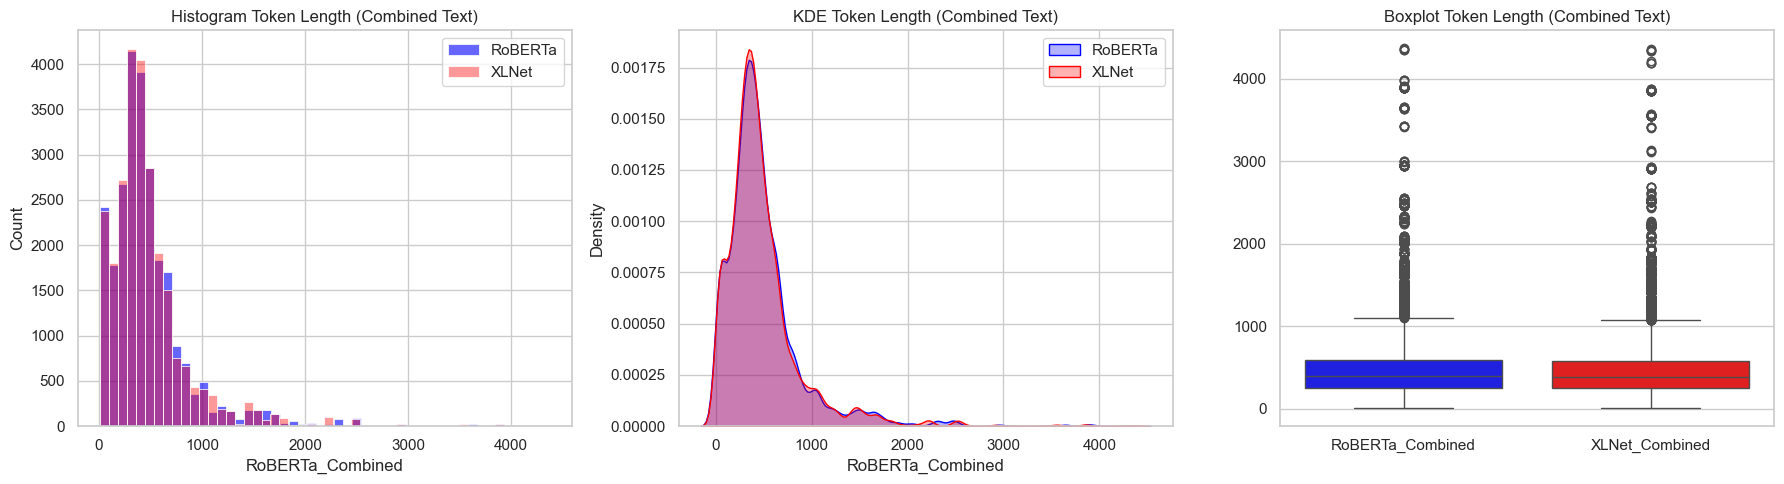

In [11]:
# 1. Meng-load tokenizers
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
xlnet_tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased')

def count_tokens(text, tokenizer):
    # Menggunakan metode yang cepat untuk menghitung token length (tanpa padding/truncation)
    # str() dipastikan agar tidak error bila ada nilai null/float
    return len(tokenizer.tokenize(str(text)))

# 2. Persiapan DataFrame (Menggunakan df_test yang ada pada notebook Anda)
sample_df = df_test.copy()

print("Memproses tokenisasi RoBERTa dan XLNet... Mohon tunggu.")

if 'Headline' in sample_df.columns and 'articleBody' in sample_df.columns:
    sample_df['Combined_Text'] = sample_df['Headline'] + " " + sample_df['articleBody']
    
    # 3. Tokenisasi RoBERTa
    sample_df['RoBERTa_Headline'] = sample_df['Headline'].apply(lambda x: count_tokens(x, roberta_tokenizer))
    sample_df['RoBERTa_Body'] = sample_df['articleBody'].apply(lambda x: count_tokens(x, roberta_tokenizer))
    sample_df['RoBERTa_Combined'] = sample_df['Combined_Text'].apply(lambda x: count_tokens(x, roberta_tokenizer))
    
    # 4. Tokenisasi XLNet
    sample_df['XLNet_Headline'] = sample_df['Headline'].apply(lambda x: count_tokens(x, xlnet_tokenizer))
    sample_df['XLNet_Body'] = sample_df['articleBody'].apply(lambda x: count_tokens(x, xlnet_tokenizer))
    sample_df['XLNet_Combined'] = sample_df['Combined_Text'].apply(lambda x: count_tokens(x, xlnet_tokenizer))
    
    print("Tokenisasi Selesai.\n")
    
    # 5. Buat fungsi ringkasan statistik
    def token_summary(series):
        return {
            'Mean': series.mean(),
            'Median': series.median(),
            'P90': np.percentile(series, 90),
            'P95': np.percentile(series, 95),
            'P99': np.percentile(series, 99),
            'Max': series.max(),
            '> 512': (series > 512).mean() * 100,
            '> 1024': (series > 1024).mean() * 100,
            '> 2048': (series > 2048).mean() * 100,
            '> 4096': (series > 4096).mean() * 100
        }
    
    # Menggabungkan summary untuk RoBERTa dan XLNet ke dalam satu tabel
    summary_df = pd.DataFrame({
        'RoBERTa Headline': token_summary(sample_df['RoBERTa_Headline']),
        'RoBERTa Body': token_summary(sample_df['RoBERTa_Body']),
        'RoBERTa Combined': token_summary(sample_df['RoBERTa_Combined']),
        'XLNet Headline': token_summary(sample_df['XLNet_Headline']),
        'XLNet Body': token_summary(sample_df['XLNet_Body']),
        'XLNet Combined': token_summary(sample_df['XLNet_Combined'])
    }).T
    
    print("Statistik Panjang Token:")
    display(summary_df)
    
    # 6. Visualisasi Komparatif
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Histogram
    sns.histplot(sample_df['RoBERTa_Combined'], bins=50, ax=axes[0], color='blue', alpha=0.6, label='RoBERTa')
    sns.histplot(sample_df['XLNet_Combined'], bins=50, ax=axes[0], color='red', alpha=0.4, label='XLNet')
    axes[0].set_title('Histogram Token Length (Combined Text)')
    axes[0].legend()
    
    # KDE Plot
    sns.kdeplot(sample_df['RoBERTa_Combined'], fill=True, ax=axes[1], color='blue', label='RoBERTa', alpha=0.3)
    sns.kdeplot(sample_df['XLNet_Combined'], fill=True, ax=axes[1], color='red', label='XLNet', alpha=0.3)
    axes[1].set_title('KDE Token Length (Combined Text)')
    axes[1].legend()
    
    # Boxplot
    sns.boxplot(data=sample_df[['RoBERTa_Combined', 'XLNet_Combined']], ax=axes[2], palette=['blue', 'red'])
    axes[2].set_title('Boxplot Token Length (Combined Text)')
    
    plt.tight_layout()
    plt.show()
else:
    print("Kolom 'Headline' atau 'articleBody' tidak ditemukan di dalam dataframe.")

**Kesimpulan**: Nilai median token gabungan (Combined) berada di kisaran 387–398 token, yang ternyata sedikit lebih pendek dibandingkan data sebelumnya (423 token). Tingkat pemotongan data (> 512) juga sedikit membaik, turun menjadi sekitar 32% (dari sebelumnya ~38%).


## Analisis Frekuensi Kata

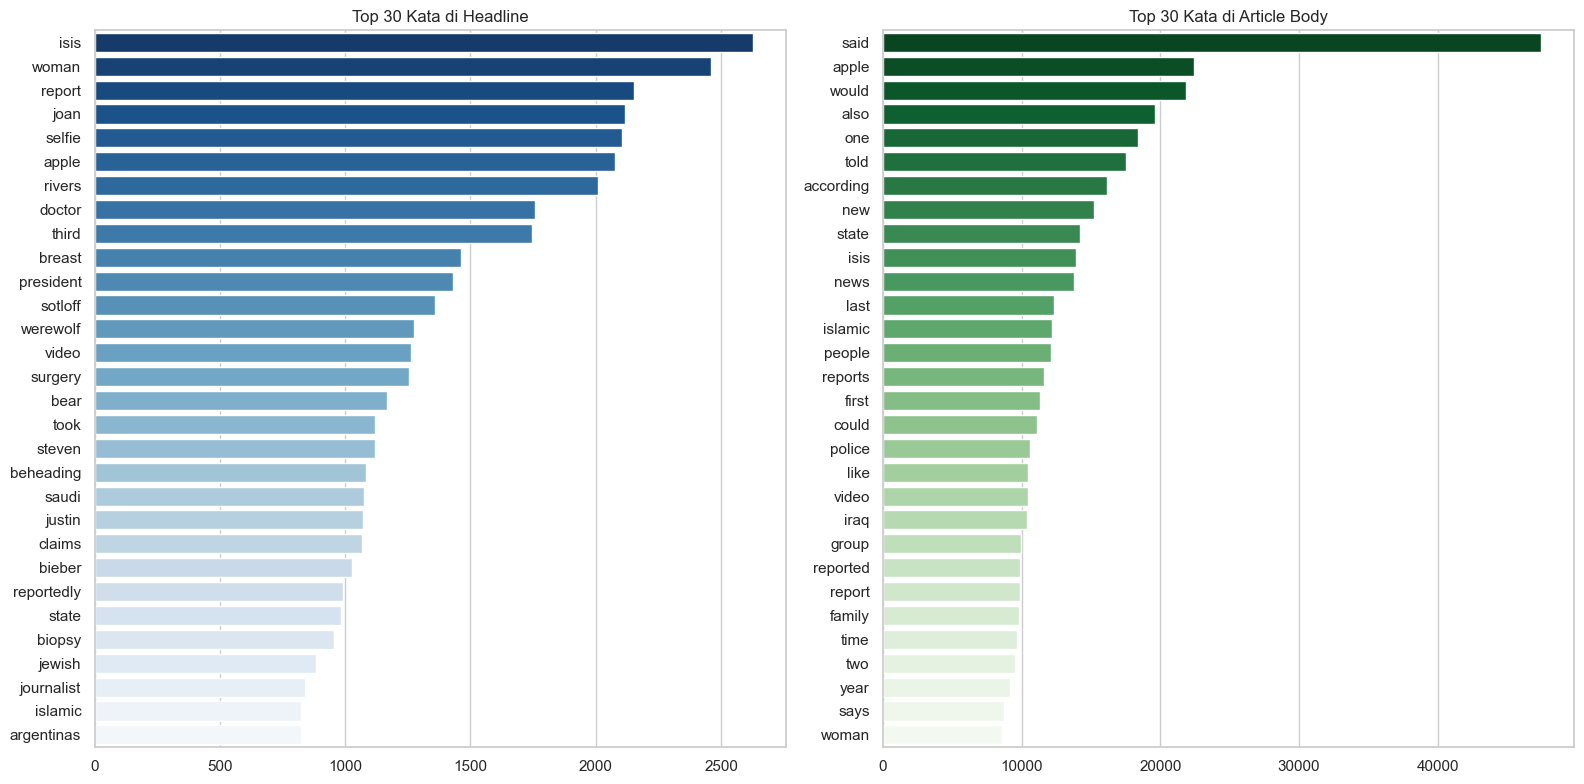

In [12]:
from nltk.corpus import stopwords
import nltk
try:
    stop_words = set(stopwords.words('english'))
except:
    nltk.download('stopwords')
    stop_words = set(stopwords.words('english'))

def get_top_words(series, n=30):
    all_words = ' '.join(series.astype(str).str.lower().str.replace(r'[^a-z\s]', '', regex=True)).split()
    words = [w for w in all_words if w not in stop_words and len(w) > 2]
    return Counter(words).most_common(n)

top_headline = get_top_words(df_test['Headline'])
top_body = get_top_words(df_test['articleBody'])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(x=[w[1] for w in top_headline], y=[w[0] for w in top_headline], ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 30 Kata di Headline')

sns.barplot(x=[w[1] for w in top_body], y=[w[0] for w in top_body], ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 30 Kata di Article Body')

plt.tight_layout()
plt.show()

## Analisis WordCloud

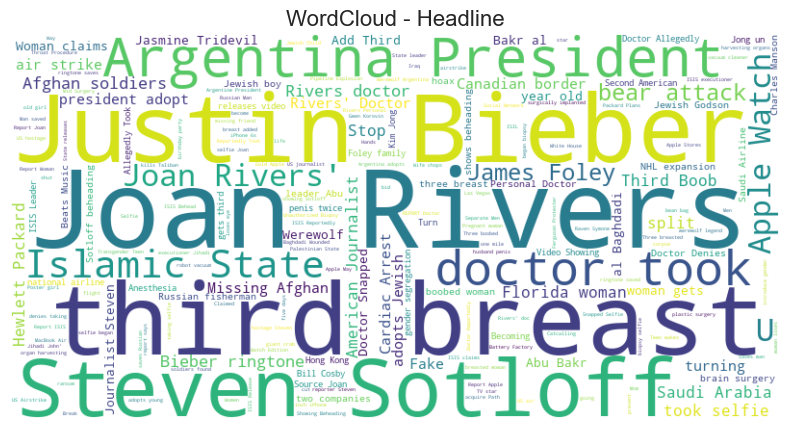

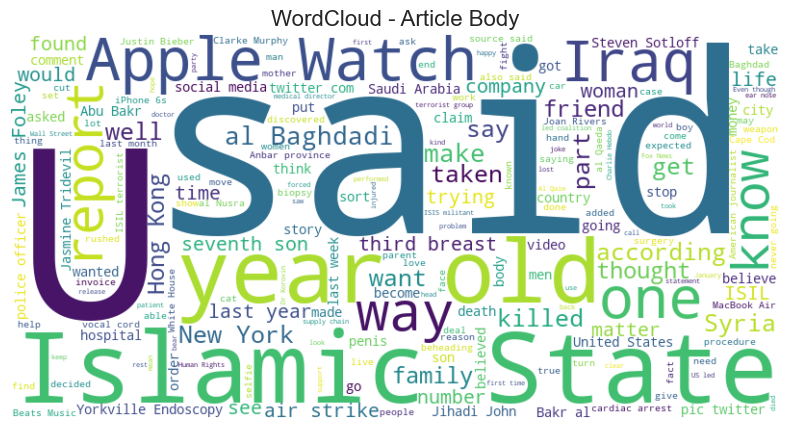

In [13]:
def plot_wordcloud(series, title):
    text = ' '.join(series.astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

plot_wordcloud(df_test['Headline'], 'WordCloud - Headline')
plot_wordcloud(df_test['articleBody'], 'WordCloud - Article Body')

## Analisis Kualitas Teks

,Count,Percentage (%)
URL,913,3.592649
HTML,304,1.196238
Email,1082,4.257663
Non-ASCII,16250,63.943651
MultipleWhitespace,22136,87.105025
ExcessivePunct,192,0.755519


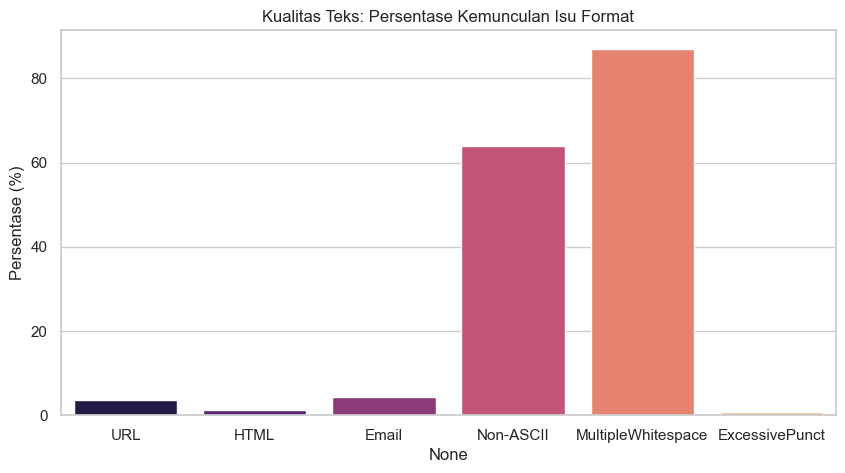

Contoh Teks dengan Karakter Non-ASCII:


,articleBody
19,A bereaved Afghan mother took revenge on the T...
20,A bereaved Afghan mother took revenge on the T...
21,A bereaved Afghan mother took revenge on the T...


In [14]:
import re

url_pattern = re.compile(r'https?://\S+|www\.\S+')
html_pattern = re.compile(r'<.*?>')
email_pattern = re.compile(r'\S+@\S+')
unicode_pattern = re.compile(r'[^\x00-\x7F]+')
multiple_ws_pattern = re.compile(r'\s{2,}')
punct_pattern = re.compile(r'[?!.]{4,}')

def check_quality(text):
    text = str(text)
    return pd.Series([
        bool(url_pattern.search(text)),
        bool(html_pattern.search(text)),
        bool(email_pattern.search(text)),
        bool(unicode_pattern.search(text)),
        bool(multiple_ws_pattern.search(text)),
        bool(punct_pattern.search(text))
    ])

qual_df = df_test['articleBody'].apply(check_quality)
qual_df.columns = ['URL', 'HTML', 'Email', 'Non-ASCII', 'MultipleWhitespace', 'ExcessivePunct']

qual_sums = qual_df.sum()
qual_pct = (qual_sums / len(df_test)) * 100

qual_res = pd.DataFrame({'Count': qual_sums, 'Percentage (%)': qual_pct})
display(qual_res)

plt.figure(figsize=(10, 5))
sns.barplot(x=qual_res.index, y=qual_res['Percentage (%)'], palette='magma')
plt.title('Kualitas Teks: Persentase Kemunculan Isu Format')
plt.ylabel('Persentase (%)')
plt.show()

print("Contoh Teks dengan Karakter Non-ASCII:")
display(df_test.loc[qual_df['Non-ASCII']].head(3)[['articleBody']])


**Kesimpulan**: Hasil evaluasi menunjukkan bahwa data test memiliki tingkat noise yang signifikan. Permasalahan sangat didominasi oleh dua faktor utama: Spasi Ganda / Multiple Whitespace yang berdampak pada 87,1% data, serta Karakter Non-ASCII yang ditemukan pada 63,9% data. Elemen pengganggu lainnya seperti tautan URL (3,5%), alamat email (4,2%), dan tag HTML (1,1%) juga turut terdeteksi. Oleh karena itu, tahap pembersihan teks (preprocessing) mutlak diperlukan dan harus diterapkan dengan metode yang sama persis seperti pada data latih.